In [22]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
from scipy.stats import spearmanrho
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons


In [40]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 8
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 1
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 200
    analysis_type = "RSA"
    tick_step = 100
    min_peak_percent = .2
    negative_lim = .8
    min_fit_cutoff = .002
    figs_folder = "/Users/tizianocausin/gdrive/presentations/posters/CAOs26/figs"
    save_figs = True
    title_fontsize=40
    labels_fontsize = 30
    ticks_fontsize = 15
    legend_fontsize=40

cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
if cfg.model_name == "alexnet":
    layers = layers[1:]
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

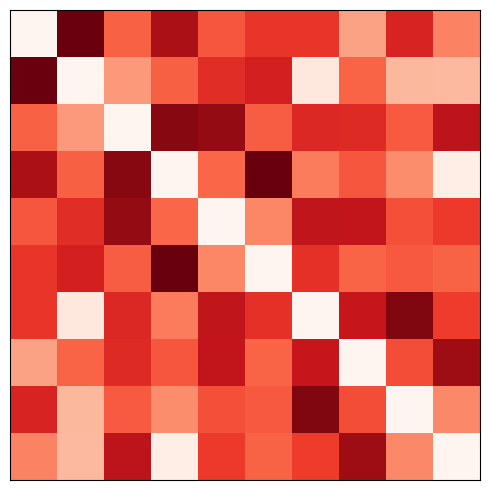

In [24]:
rng = np.random.default_rng(1)

A = rng.random((10, 10))
M = (A + A.T) / 2
# M[[2, 4, 7], :] = .1
# M[:, [2, 4, 7]] = .1
# M += (A + A.T)*0.5 / 2
np.fill_diagonal(M, 0)
plt.figure(figsize=(6, 5))
# plt.imshow(M, cmap="viridis_r", interpolation="nearest")
plt.imshow(M, cmap="Reds", interpolation="nearest")
# plt.colorbar(label="value")
# plt.title("15x15 Symmetric Matrix")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
if cfg.save_figs:
    fname = f"dRSA_neu_t0.pdf"
    outpath = os.path.join(cfg.figs_folder, fname)
    plt.gcf().savefig(outpath, format="pdf", bbox_inches="tight")
plt.show()

# SUBJECTS AVERAGE

10:09:43 - sub=13 layer=layer.0.mlp.down_proj not found
10:09:43 - sub=14 layer=layer.0.mlp.down_proj not found
10:09:43 - sub=15 layer=layer.0.mlp.down_proj not found
10:09:43 - sub=20 layer=layer.0.mlp.down_proj not found
10:09:43 - sub=13 layer=layer.1.mlp.down_proj not found
10:09:43 - sub=14 layer=layer.1.mlp.down_proj not found
10:09:43 - sub=15 layer=layer.1.mlp.down_proj not found
10:09:44 - sub=13 layer=layer.2.mlp.down_proj not found
10:09:44 - sub=14 layer=layer.2.mlp.down_proj not found
10:09:44 - sub=15 layer=layer.2.mlp.down_proj not found
10:09:44 - sub=13 layer=layer.3.mlp.down_proj not found
10:09:44 - sub=14 layer=layer.3.mlp.down_proj not found
10:09:44 - sub=15 layer=layer.3.mlp.down_proj not found
10:09:44 - sub=13 layer=layer.4.mlp.down_proj not found
10:09:44 - sub=14 layer=layer.4.mlp.down_proj not found
10:09:44 - sub=15 layer=layer.4.mlp.down_proj not found
10:09:44 - sub=13 layer=layer.5.mlp.down_proj not found
10:09:44 - sub=14 layer=layer.5.mlp.down_proj no

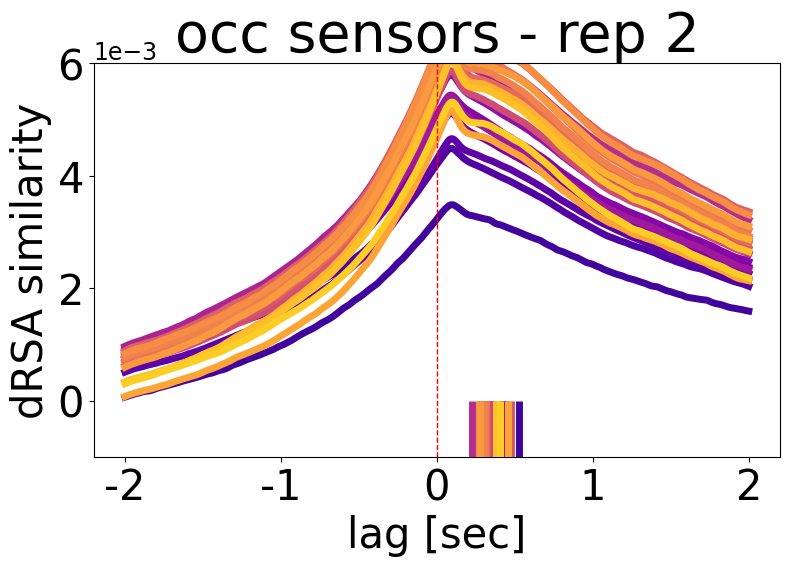

In [25]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---

cmap = truncate_colormap(plt.cm.plasma)
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(np.round(ticks / cfg.neu_fs, 2)).astype(int)
ticks += cfg.max_lag
plt.figure(figsize=(8, 6))
all_peaks = []
all_centroids = []
avg_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        sub_counter = 0
        # lagplot_sum = np.zeros(cfg.max_lag*2 +1, cfg.max_lag*2 +1)
        lagplot_sum = np.zeros((cfg.len_or_lag, cfg.len_or_lag))
        for i_sub in config["subjects"]:
            try:
                res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = loadmat(res_path)["RSA"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            all_peaks.append([idx, peak_lag])
            weights = lagplot.copy()
            weights[weights < 0] = 0  # optional but recommended
            if not np.all(weights==0):
                centroid = np.sum(lags * weights) / np.sum(weights)
                centroid_lag = np.round(centroid / cfg.neu_fs, 5)
                all_centroids.append([idx, centroid_lag])
            lagplot_sum += res
        avg_lagplot = lagplot_sum/sub_counter
        avg_lagplot = get_lagplot(avg_lagplot, max_lag=cfg.max_lag)
        lagplots.append(avg_lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(avg_lagplot)
        
        centroid_lag = get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs)
        if np.max(lagplot)>cfg.min_fit_cutoff:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            peak_val = avg_lagplot[peak_idx]
            peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            peaks.append(peak_lag)
            centroids.append(centroid_lag)
        
        plt.plot(avg_lagplot, linewidth=5, label=f"Block {idx}", color=colors[idx])
        avg_centroids.append(get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent))
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(avg_lagplot)), avg_lagplot)
            plt.vlines(
                centroid_idx,
                -.001,
                -.001 + 0.001,
                color=colors[idx],
                linewidth=5,  # increased line width
                zorder=15,
            )
        plt.ylim([-.001,.006])
plt.ylabel("dRSA similarity", fontsize=cfg.labels_fontsize)
plt.xlabel("lag [sec]", fontsize=cfg.labels_fontsize)
plt.xticks(ticks, ticks_labels, fontsize=cfg.ticks_fontsize)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
plt.ticklabel_format(axis='y', style='sci', scilimits=(-0, -0))
plt.gca().yaxis.get_offset_text().set_fontsize(17)
plt.tick_params(labelsize=cfg.labels_fontsize)
plt.title(f"{cfg.sensors_group} sensors - rep {cfg.repetition+1}", fontsize=cfg.title_fontsize)
# plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
if cfg.save_figs:
    fname = f"subavg_{cfg.model_name}_rep{cfg.repetition+1}_{cfg.analysis_type}.pdf"
    outpath = os.path.join(cfg.figs_folder, fname)
    plt.gcf().savefig(outpath, format="pdf", bbox_inches="tight")
    print(outpath)

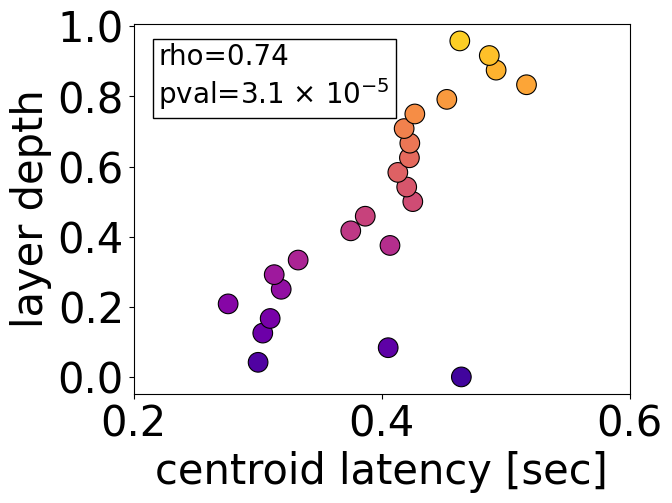

In [26]:
cmap = truncate_colormap(plt.cm.plasma)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
rho = spearmanrho(np.arange(len(avg_centroids)), avg_centroids)
r = np.corrcoef(np.arange(len(avg_centroids)), avg_centroids)[0,1]
fig, ax = plt.subplots(1)
ax.scatter(avg_centroids, np.arange(len(avg_centroids))/len(avg_centroids),  c=colors[:len(avg_centroids)], s=200, edgecolors='k', linewidths=0.8)
pval_str = f"{rho.pvalue:.1e}"
mantissa, exponent = pval_str.split("e")
exponent = int(exponent)  # removes leading zeros like -02 -> -2

label = f"rho={rho.statistic:.2f}\npval={mantissa} × 10$^{{{exponent}}}$"
ax.text(
    0.05, 0.95,              # slightly inside the corner
    f"{label}",
    transform=ax.transAxes,
    ha='left',               # horizontal alignment
    va='top',                # vertical alignment
    bbox=dict(facecolor='white', edgecolor='black'), 
    fontsize=cfg.legend_fontsize-20
);
# ax.set_xlim([.450, .550])
ax.set_xlim([.2, .6])
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_ylabel("layer depth", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency [sec]", fontsize=cfg.labels_fontsize)
if cfg.save_figs:
    fname = f"layers-latency_{cfg.model_name}_rep{cfg.repetition+1}_{cfg.analysis_type}.pdf"
    outpath = os.path.join(cfg.figs_folder, fname)
    fig.savefig(outpath, format="pdf", bbox_inches="tight")
    print(outpath)

10:09:46 - sub=8 layer=layer.0.mlp.down_proj not found
10:09:46 - sub=9 layer=layer.0.mlp.down_proj not found
10:09:46 - sub=10 layer=layer.0.mlp.down_proj not found
10:09:46 - sub=11 layer=layer.0.mlp.down_proj not found
10:09:46 - sub=12 layer=layer.0.mlp.down_proj not found
10:09:46 - sub=8 layer=layer.1.mlp.down_proj not found
10:09:46 - sub=9 layer=layer.1.mlp.down_proj not found
10:09:46 - sub=10 layer=layer.1.mlp.down_proj not found
10:09:46 - sub=11 layer=layer.1.mlp.down_proj not found
10:09:46 - sub=12 layer=layer.1.mlp.down_proj not found
10:09:46 - sub=8 layer=layer.2.mlp.down_proj not found
10:09:46 - sub=9 layer=layer.2.mlp.down_proj not found
10:09:46 - sub=10 layer=layer.2.mlp.down_proj not found
10:09:46 - sub=11 layer=layer.2.mlp.down_proj not found
10:09:46 - sub=12 layer=layer.2.mlp.down_proj not found
10:09:46 - sub=8 layer=layer.3.mlp.down_proj not found
10:09:46 - sub=9 layer=layer.3.mlp.down_proj not found
10:09:46 - sub=10 layer=layer.3.mlp.down_proj not found


/var/folders/nw/yf48zdjj1m5012281wx_pzhc0000gn/T/ipykernel_12863/2576218931.py:46: RuntimeWarning: invalid value encountered in divide
  avg_lagplot = lagplot_sum/sub_counter
/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src/useful_stuff/general_utils/utils.py:182: RuntimeWarning: Mean of empty slice
  lagplot[max_lag] = stat(d)
/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src/useful_stuff/general_utils/utils.py:185: RuntimeWarning: Mean of empty slice
  lagplot[max_lag+tau] = stat(d) # append because the lower triangular correspond to a positive offset between data1 and data2
/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src/useful_stuff/general_utils/utils.py:187: RuntimeWarning: Mean of empty slice
  lagplot[max_lag-tau] = stat(d) # appendleft because the upper triangular correspond to a negative offset between data1 and data2
/Users/tizianocausin/Desktop/useful_stuff/python_scripts/src/useful_stuff/general_utils/utils.py:1164: RuntimeWarning: inval

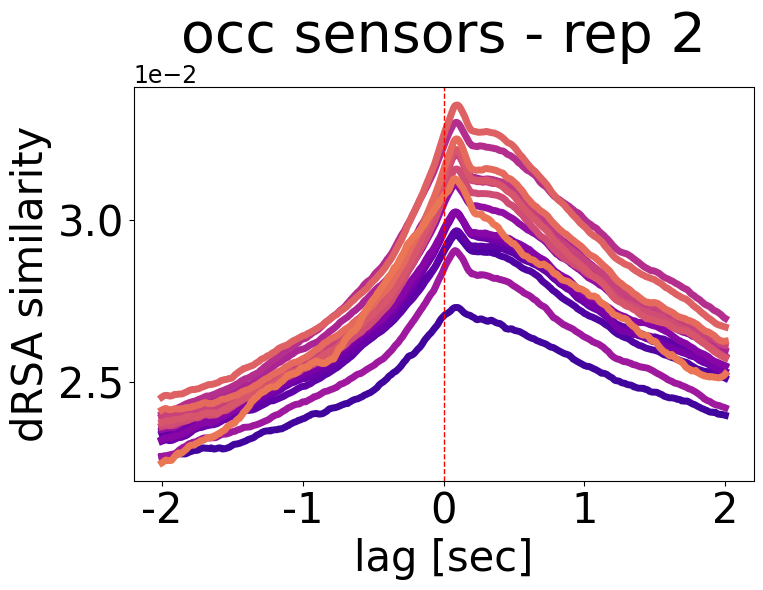

In [27]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---

cmap = truncate_colormap(plt.cm.plasma)
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(np.round(ticks / cfg.neu_fs, 2)).astype(int)
ticks += cfg.max_lag
plt.figure(figsize=(8, 6))
all_peaks = []
all_centroids = []
avg_centroids = []
lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)
for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        sub_counter = 0
        # lagplot_sum = np.zeros(cfg.max_lag*2 +1, cfg.max_lag*2 +1)
        lagplot_sum = np.zeros((cfg.len_or_lag, cfg.len_or_lag))
        for i_sub in config["subjects"][:10]:
            try:
                res_path = save_lagged_comparisons(paths, "IIA2B", i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = 1 -loadmat(res_path)["II"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            all_peaks.append([idx, peak_lag])
            weights = lagplot.copy()
            weights[weights < 0] = 0  # optional but recommended
            if not np.all(weights==0):
                centroid = np.sum(lags * weights) / np.sum(weights)
                centroid_lag = np.round(centroid / cfg.neu_fs, 5)
                all_centroids.append([idx, centroid_lag])
            lagplot_sum += res
        avg_lagplot = lagplot_sum/sub_counter
        avg_lagplot = get_lagplot(avg_lagplot, max_lag=cfg.max_lag)
        lagplots.append(avg_lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(avg_lagplot)
        
        centroid_lag = get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs)
        if np.max(lagplot)>cfg.min_fit_cutoff:
            if np.sum(lagplot < 0) < cfg.negative_lim*len(lagplot):
                centroid_lag = get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent)
            else:
                centroid_lag = np.nan
        else: 
            centroid_lag = np.nan
        if not np.isnan(centroid_lag):
            peak_val = avg_lagplot[peak_idx]
            peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            peaks.append(peak_lag)
            centroids.append(centroid_lag)
        
        plt.plot(avg_lagplot, linewidth=5, label=f"Block {idx}", color=colors[idx])
        avg_centroids.append(get_centroid(avg_lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=cfg.min_peak_percent))
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(avg_lagplot)), avg_lagplot)
            # plt.vlines(
            #     centroid_idx,
            #     -.001,
            #     -.01 + 0.01,
            #     color=colors[idx],
            #     linewidth=5,  # increased line width
            #     zorder=15,
            # )
        # plt.ylim([-.001,.006])
plt.ylabel("dRSA similarity", fontsize=cfg.labels_fontsize)
plt.xlabel("lag [sec]", fontsize=cfg.labels_fontsize)
plt.xticks(ticks, ticks_labels, fontsize=cfg.ticks_fontsize)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
plt.ticklabel_format(axis='y', style='sci', scilimits=(-0, -0))
plt.gca().yaxis.get_offset_text().set_fontsize(17)
plt.tick_params(labelsize=cfg.labels_fontsize)
plt.title(f"{cfg.sensors_group} sensors - rep {cfg.repetition+1}", fontsize=cfg.title_fontsize)
# plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
if cfg.save_figs:
    fname = f"subavg_{cfg.model_name}_rep{cfg.repetition+1}_II_A2B.pdf"
    outpath = os.path.join(cfg.figs_folder, fname)
    plt.gcf().savefig(outpath, format="pdf", bbox_inches="tight")
    print(outpath)

ValueError: not enough values to unpack (expected 2, got 1)

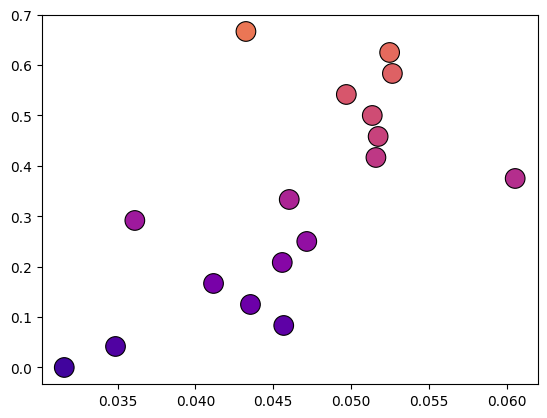

In [28]:
cmap = truncate_colormap(plt.cm.plasma)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
rho = spearmanrho(np.arange(len(avg_centroids)), avg_centroids)
r = np.corrcoef(np.arange(len(avg_centroids)), avg_centroids)[0,1]
fig, ax = plt.subplots(1)
ax.scatter(avg_centroids, np.arange(len(avg_centroids))/len(avg_centroids),  c=colors[:len(avg_centroids)], s=200, edgecolors='k', linewidths=0.8)
pval_str = f"{rho.pvalue:.1e}"
mantissa, exponent = pval_str.split("e")
exponent = int(exponent)  # removes leading zeros like -02 -> -2

label = f"rho={rho.statistic:.2f}\npval={mantissa} × 10$^{{{exponent}}}$"
ax.text(
    0.05, 0.95,              # slightly inside the corner
    f"{label}",
    transform=ax.transAxes,
    ha='left',               # horizontal alignment
    va='top',                # vertical alignment
    bbox=dict(facecolor='white', edgecolor='black'), 
    fontsize=cfg.legend_fontsize-20
);
ax.set_xlim([.015, .032])
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_ylabel("layer depth", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency [sec]", fontsize=cfg.labels_fontsize)
if cfg.save_figs:
    fname = f"layers-latency_{cfg.model_name}_rep{cfg.repetition+1}_IIA2B.pdf"
    outpath = os.path.join(cfg.figs_folder, fname)
    fig.savefig(outpath, format="pdf", bbox_inches="tight")
    print(outpath)

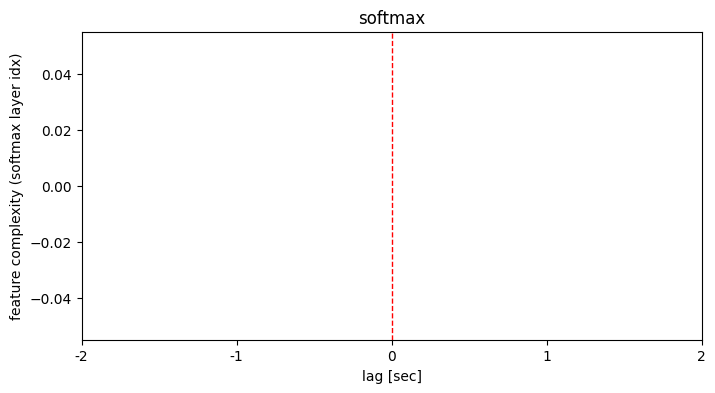

In [29]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax_lp = []


temp_range = np.arange(0.001, 1, 0.1)
cmap = truncate_colormap(plt.cm.RdBu)
colors = cmap(np.linspace(0, 1, len(temp_range)))[::-1]
fig, ax = plt.subplots(1,figsize=(8,4))

for idx, temp in enumerate(temp_range[:1]):
    softmax_lp = []
    for t in range(lps.shape[1]):
        softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0])/lps.shape[0])
        if temp==temp_range[-1]:
            hardmax_lp.append(np.argmax(lps[:,t]))
    # plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
    ax.set_xticks(ticks, ticks_labels)
    ax.set_xlabel("lag [sec]")
    ax.set_ylabel("feature complexity (softmax layer idx)")
    ax.set_title("softmax")


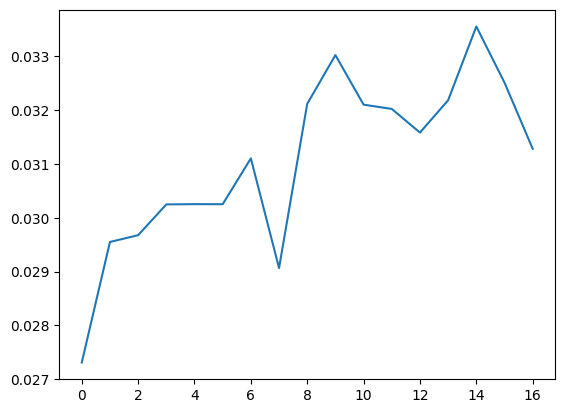

In [30]:
max_vals_rep0 = []
for lp in lagplots:
    max_vals_rep0.append(np.max(lp))
plt.plot(max_vals_rep0)

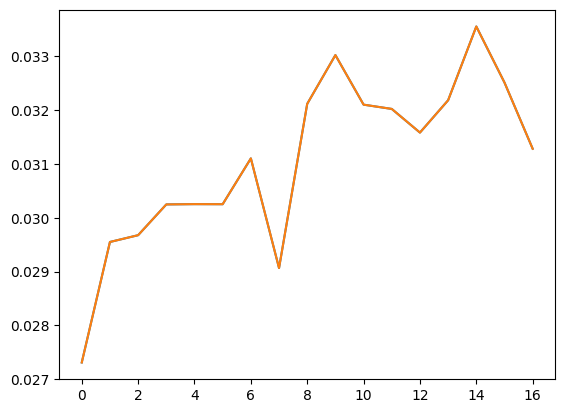

In [31]:
max_vals_rep1 = []
for lp in lagplots:
    max_vals_rep1.append(np.max(lp))
plt.plot(max_vals_rep0)
plt.plot(max_vals_rep1)

(22, 50)


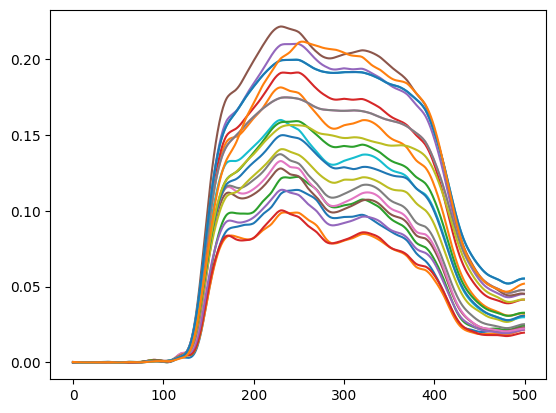

In [32]:
p1 = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSA.mat"
p_interp = "/Users/tizianocausin/Downloads/baby1_220226_AlexNet_RSAinterpolated.mat"
rsa = loadmat(p1)['rsa']
print(rsa.shape)
rsa_interp = loadmat(p_interp)['rsasm']
plt.plot(rsa_interp.T);

In [33]:
layers_depths = []
abs_max = []
n_layers, n_timepts = rsa_interp.shape
layers_idx = np.arange(1, n_layers+1)
T = .05
for t in range(n_timepts):
    mods = rsa_interp[:, t]
    layer_depth_t = layers_idx@softmax(mods, T=T)
    abs_max.append(np.argmax(mods))
    layers_depths.append(layer_depth_t)



In [34]:
from useful_stuff.general_utils.utils import softmax
layers_depths = []
abs_max = []
n_layers, n_timepts = rsa_interp.shape
layers_idx = np.arange(1, n_layers+1)
T = .05
for t in range(n_timepts):
    mods = rsa_interp[:, t]
    layer_depth_t = layers_idx@softmax(mods, T=T)
    abs_max.append(np.argmax(mods))
    layers_depths.append(layer_depth_t)

    


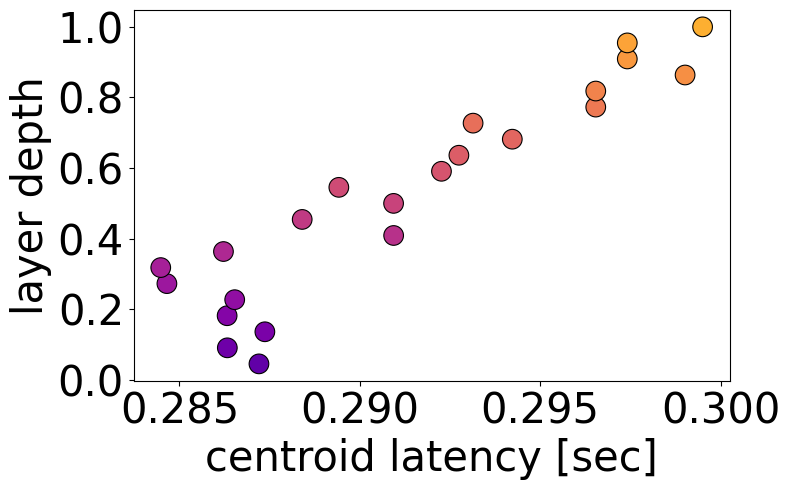

In [42]:
centroids = []
for l in range(n_layers):
    centroids.append(np.average(np.arange(n_timepts), weights=rsa_interp[l,:]))
t_min = min(centroids)
t_max = max(centroids)

cmap = truncate_colormap(plt.cm.plasma)
colors = cmap(np.linspace(0.1, 0.9, len(layers_idx)))  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))

n_ticks = 6
ticks = np.round(np.linspace(t_min, t_max, n_ticks))
ax.scatter(np.array(centroids)/1000, layers_idx/len(layers_idx),  c=colors[:len(avg_centroids)], s=200, edgecolors='k', linewidths=0.8)
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_yticks([0, .2, .4, .6, .8, 1])
ax.set_ylabel("layer depth", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency [sec]", fontsize=cfg.labels_fontsize)
# ax.set_title("monkey B1 - img responses", fontsize=cfg.title_fontsize)
if cfg.save_figs:
    fig.tight_layout()
    plt.savefig(f"{cfg.figs_folder}/B1_alexnet.svg")

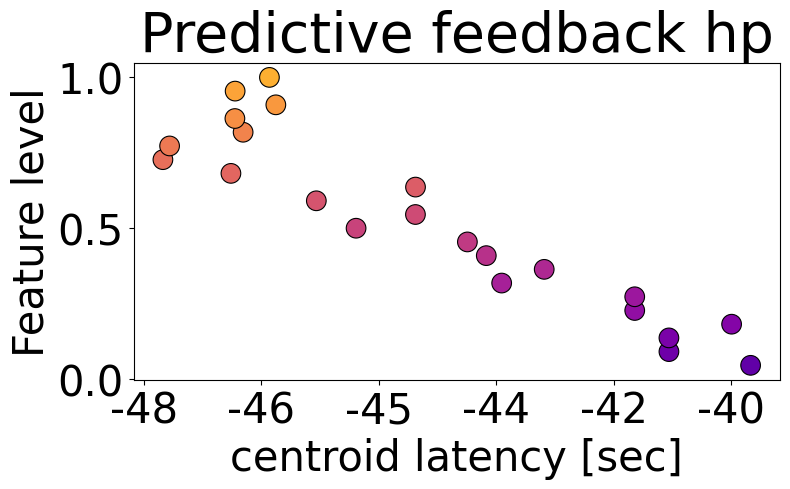

In [ ]:
centroids = []
for l in range(n_layers):
    centroids.append(np.average(np.arange(n_timepts), weights=rsa_interp[l,:]))
t_min = min(centroids)
t_max = max(centroids)

cmap = truncate_colormap(plt.cm.plasma)
colors = cmap(np.linspace(0.1, 0.9, len(layers_idx)))  # reverse for purple → light blue
fig, ax = plt.subplots(figsize=(8, 5))

n_ticks = 6
ticks = np.round(np.linspace(t_min, t_max, n_ticks))
ax.scatter(centroids[::-1], layers_idx/len(layers_idx), c=colors[:len(avg_centroids)], s=200, edgecolors='k', linewidths=0.8)
ax.tick_params(labelsize=cfg.labels_fontsize)
tick_lab = np.round(ticks/2).astype(int) - 190
ax.set_xticks(ticks, tick_lab)

ax.set_ylabel("Feature level", fontsize=cfg.labels_fontsize)
ax.set_xlabel("centroid latency [sec]", fontsize=cfg.labels_fontsize);
ax.set_title("Predictive feedback hp", fontsize=cfg.title_fontsize)
fig.tight_layout()
plt.savefig(f"{cfg.figs_folder}/feedback_hp.svg")

In [ ]:
fig, ax = plt.subplots(figsize=(1.5, 5))
fig.subplots_adjust(left=0.35, right=0.75)

sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
# cbar.ax.tick_params()
cbar.ax.set_xticks([])
cbar.ax.set_yticks([])
ax.remove()
plt.show()

fig.savefig(f"{cfg.figs_folder}/colorbar.pdf")

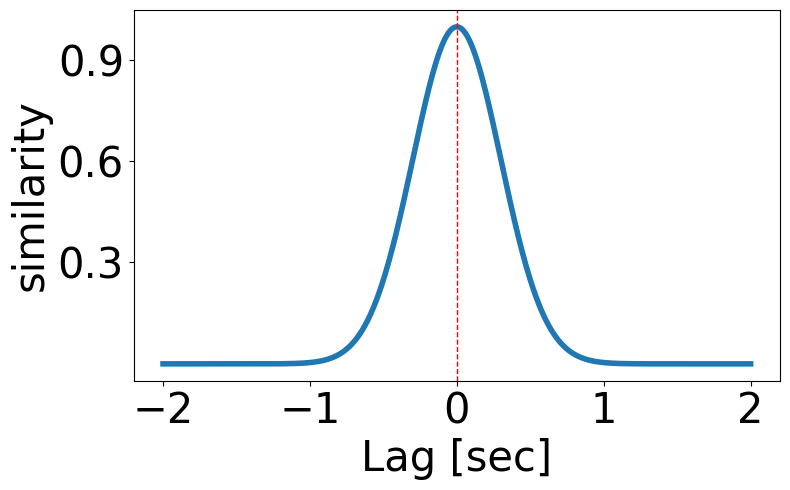

In [34]:
x = np.linspace(-2, 2, 1000)
fig, ax = plt.subplots(figsize=(8, 5))
means = [0]
std = .3
for mean in means:
    y = (1 / (std * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x-mean)/std)**2)
    ax.plot(x, y, linewidth=4, color="tab:blue")
# ax.legend(fontsize=cfg.legend_fontsize)
ax.set_yticks([.4, .8, 1.2])
ax.set_yticklabels([.3, .6, .9])
ax.set_xticks([-2, -1, 0, 1, 2])
ax.tick_params(labelsize=cfg.labels_fontsize)
ax.set_xlabel("Lag [sec]", fontsize=cfg.labels_fontsize)
ax.set_ylabel("similarity", fontsize=cfg.labels_fontsize)
# ax.set_title("static modeling dynamic condition", fontsize=cfg.title_fontsize)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.axvline(0, color="r", linestyle="--", linewidth=1)
plt.tight_layout()
plt.savefig(f"{cfg.figs_folder}/example_lagplot.pdf")
plt.show()